In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

<h2>Получите данные и загрузите их в рабочую среду. (Jupyter Notebook или другую)</h2>

In [3]:
# Загружаем данные
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 
    'marital-status', 'occupation', 'relationship', 'race', 'sex', 
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]
df = pd.read_csv(url, names=column_names, na_values='?', skipinitialspace=True)

<h2>Проведите первичный анализ:</h2>
a) проверьте данные на пропуски. Удалите в случае обнаружения.

* Предложите альтернативный способ работы с пропусками

b) постройте 1-2 графика на выбор. Визуализация должна быть основана на исследуемых данных и быть полезной (из графика можно сделать вывод об особенностях датасета/класса/признака)</b>

c) преобразуйте категориальные признаки</b>

In [4]:
print(f"Размер данных: {df.shape}")
df.head(100)

Размер данных: (32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,29,Local-gov,115585,Some-college,10,Never-married,Handlers-cleaners,Not-in-family,White,Male,0,0,50,United-States,<=50K
96,48,Self-emp-not-inc,191277,Doctorate,16,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,1902,60,United-States,>50K
97,37,Private,202683,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,0,0,48,United-States,>50K
98,48,Private,171095,Assoc-acdm,12,Divorced,Exec-managerial,Unmarried,White,Female,0,0,40,England,<=50K


In [5]:
# Считаем пропуски
print("Пропуски по столбцам:")
print(df.isnull().sum())

Пропуски по столбцам:
age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64


In [6]:
# Удаляем строки с пропусками
df_cleaned = df.dropna()
# Считаем пропуски
print("Пропуски по столбцам:")
print(df_cleaned.isnull().sum())
#Альтернатива: заполнение модой (самым частым значением)
# for col in df.columns:
#     if df[col].dtype == 'object':
#         df[col].fillna(df[col].mode()[0], inplace=True)
#     else:
#         df[col].fillna(df[col].median(), inplace=True)

Пропуски по столбцам:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


<p>Визуализация</p>

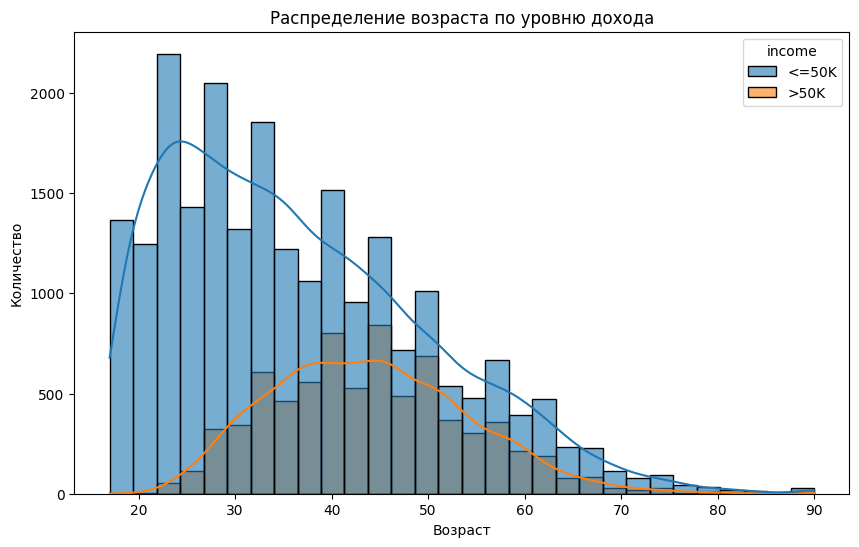

In [7]:
#Распределение возраста по уровню дохода:

plt.figure(figsize=(10, 6))
sns.histplot(data=df_cleaned, x='age', hue='income', bins=30, kde=True, alpha=0.6)
plt.title('Распределение возраста по уровню дохода')
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.show()

<p>Люди с доходом >50K в основном старше 35 лет. Пик дохода приходится на 40-50 лет.</p>

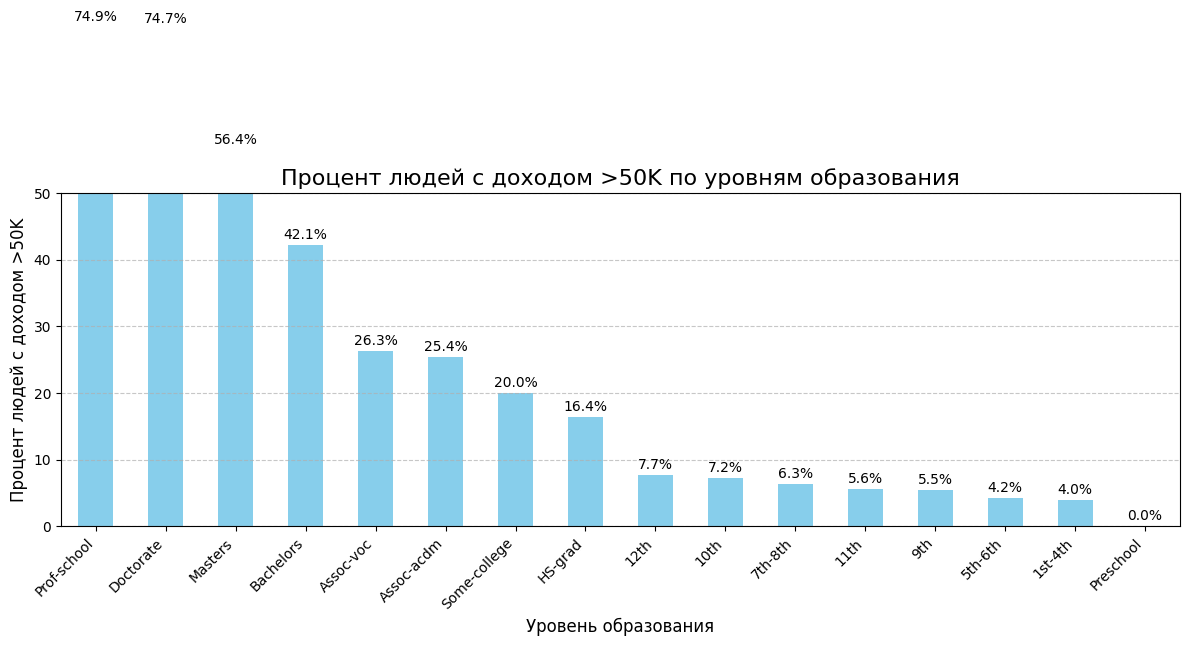

In [8]:
#Зависимость дохода от образования:
plt.figure(figsize=(12, 8))

# Рассчитываем процент людей с доходом >50K для каждого уровня образования
education_stats = df_cleaned.groupby('education')['income'].apply(
    lambda x: (x == '>50K').mean() * 100
).sort_values(ascending=False)

# Создаем график
ax = education_stats.plot(kind='bar', color='skyblue')

# Добавляем подписи значений
for i, v in enumerate(education_stats):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom')

# Настраиваем оформление
plt.title('Процент людей с доходом >50K по уровням образования', fontsize=16)
plt.xlabel('Уровень образования', fontsize=12)
plt.ylabel('Процент людей с доходом >50K', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 50)  # Устанавливаем пределы оси Y
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

<p>Люди с профессиональным образованием (Prof-school) имеют наибольший шанс высокого дохода</p>

In [9]:
# Отделяем целевую переменную
y = df_cleaned['income'].map({'<=50K': 0, '>50K': 1})  # Бинарное кодирование

# Удаляем исходный столбец income
X = df_cleaned.drop('income', axis=1)

# Применяем One-Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

# Проверяем результат
print(f"Размер данных после кодирования: {X_encoded.shape}")

Размер данных после кодирования: (30162, 96)


<p>Разделим выборки</p>

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,  # Признаки после One-Hot кодирования
    y,          # Целевая переменная (0 для <=50K, 1 для >50K)
    test_size=0.2,
    random_state=42  # Для воспроизводимости результатов
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (24129, 96)
Размер тестовой выборки: (6033, 96)


In [ ]:
from warnings import filterwarnings
filterwarnings('ignore')
# Создаем и обучаем модель лог.регрессии
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
# SVM но linearSVC
svm = LinearSVC(random_state=42, max_iter=1000)
svm.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,42


In [ ]:
# Создаем и обучаем модель svm  - не удалось, все зависает
#svm = SVC(kernel='linear', random_state=42)
#svm.fit(X_train, y_train)

In [17]:
#Оценка логистической регрессии
logreg_score = logreg.score(X_test, y_test)
print(f"Точность логистической регрессии: {logreg_score:.4f}")
# Оценка SVM
svm_score = svm.score(X_test, y_test)
print(f"Точность метода опорных векторов: {svm_score:.4f}")

Точность логистической регрессии: 0.8454
Точность метода опорных векторов: 0.7915


<h2>Дописать выводы</h2>

Преобразования данных

Обработка пропусков: Удалили строки с отсутствующими значениями

Преобразование категориальных признаков: Применили One-Hot Encoding для всех нечисловых признаков

Кодирование целевой переменной: Преобразовали '<=50K' → 0, '>50K' → 1

Сравнение точности моделей

Логистическая регрессия: 84.54%

Метод опорных векторов: 79.15%

Логистическая регрессия показало в данном случае большую точность на 5% (после замены SVC на LinearSVC)


Возможные улучшение для обучения
- больше признаков для обучения
- может использование других методов обучения
- в тестовой выборке гораздо больше людей с меньшим доходов, что возможгно дает некий перекос в обучении с их данными
